<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/Insight-Sogang-Univ/insight-14th/blob/main/advanced/template/session05/practice_languagemodel.ipynb" target="_parent">
      <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
  </td>
</table>


# 🔎 RAG, langchain 실습

## 관련 라이브러리 설치

In [ ]:
# langchain 관련
!pip install -U langchain langchain-community langchain-google-genai langgraph langchain-text-splitters
# chromadb: 벡터를 저장하는 로컬 DB)
!pip install -U chromadb
# google-genai: Gemini API 공식 라이브러리
!pip install "google-genai>=1.65.0,<2.0.0"
# tavily 관련: 웹 검색 API
!pip install -U tavily-python beautifulsoup4 lxml html5lib
# 시각화 관련: langchain으로 노드 기반 파이프라인 구성
!pip install -U pydot graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.8/173.8 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1
  Attempting uninstall:

## Api키 값 입력

google gemini, tavily, langsmith api 키 값입니다!      

**알려드린 api 키는 개인 계정 키 값이기 때문에 외부 유출 ❌ 절대 깃허브에도 올리지 말아주세요!!!!!**

🔗 라이브러리 링크

* Google AI Studio : https://aistudio.google.com
  * gemini 모델들을 api로 사용하기 위한 곳
* tavily : https://www.tavily.com/
  * llm이나 agent을 위한 웹 검색 엔진 (ai 툴이랑 연동이 잘 돼요)
* langsmith : https://smith.langchain.com/
  * langchain 파이프라인을 모니터링, 추적하기 위한 곳

In [2]:
import os

# gemini api키 (원한다면 본인 계정으로 넣어도 돼요)
os.environ["GOOGLE_API_KEY"] = "*****"

# tavily api키 (원한다면 본인 계정으로 넣어도 돼요)
os.environ["TAVILY_API_KEY"] = "*****"

# langsmith api키 (원한다면 본인 계정으로 넣어도 돼요)
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_API_KEY"] = "*****"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = "practice_langgraph"



# RAG 적용 전 결과 확인해보기

In [ ]:
from google import genai
import os

# gemini 클라이언트 생성
client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

# 📌사용자 질문 -> 원하시는 질문으로 바꿔도 됩니다!!📌
question = "2026년 WBC 우승 국가를 알려주세요."

# 모델 직접 호출
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=question,
    config={
        # temperature: 모델의 창의성, 다양성을 조절하는 값. 
        # 사실 기반 답변을 받으려면 0으로 설정 (1에 가까울수록 창의적 답변)
        "temperature": 0
    }
)

print("=" * 50)
print("💡 1. RAG 적용 전 결과")
print(f"질문: {question}")
print("-" * 50)
print(response.text)
print("=" * 50)

💡 1. RAG 적용 전 결과
질문: 2026년 WBC 우승 국가를 알려주세요.
--------------------------------------------------
2026년 WBC는 아직 개최되지 않았습니다.

따라서 우승 국가를 알 수 없습니다. 2026년 3월경에 대회가 열릴 예정이며, 우승팀은 대회가 진행된 후에 결정됩니다.

직전 대회인 2023년 WBC에서는 일본이 우승했습니다. 어떤 팀이 2026년에 우승할지 예측하기는 어렵지만, 많은 야구 강국들이 치열한 경쟁을 펼칠 것으로 예상됩니다.


-> gemini 2.5 flash 모델은 2025년 여름에 출시가 된 모델이기 때문에, 최신 정보에 답변을 못하는 걸 확인할 수 있습니다!

그래서 이제 RAG를 사용해서 저희가 원하는 정보를 제대로 답변하는 모델을 만들어 볼게요!

# 📝 RAG 적용

저희는 RAG를 구축할 때, tavily라는 웹 검색 엔진을 연동해서 사용자 질문을 웹에서 검색하여 정보를 얻으려고 합니다!

간단한 구조이긴 하지만, 공부를 위해서 langchain, langgraph, langsmith까지 활용해서 답변 과정을 구성하고 모니터링까지 해보겠습니다

## 라이브러리 import

In [14]:
from typing import TypedDict, List, Any
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

# LLM / Embeddings
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings

# Search / Load / Vectorstore
from tavily import TavilyClient
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma

# Prompt & Parser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# LangGraph
from langgraph.graph import StateGraph, END



## 🟨 노드 구성 🟨

**RAGState**는 그래프 구조에 대한 스키마입니다!!<br>(말이 어렵죠? 그냥 파이프 라인에 대한 개념 정의 코드라고 생각하면 됩니다...)

<U>여러분들이 노션에서 데이터베이스 블럭을 만드는 거라고 생각하면 돼요!</U>

### 🙋🏻 노드 설명

실습에서는 6개 노드로 구성했습니다 각 노드의 역할을 알려드릴게요

* `node_search()` : **검색**
  * tavily api로 <U>url 검색</U>
* `node_load()` : **웹 문서 로드**
  * 각 url에 대해 크롤링 -> <U>'document' 형식으로 변환</U>
* `node_split()` : **청크 분할**
  * <U>'document'를 chunk 단위로 쪼개기</U>, Overlap을 적용해서 각 청크마다 겹치게 설정
* `node_index()` : **벡터 인덱스 생성**
  * 청크를 <U>임베딩 처리해서 벡터db에 저장</U> (벡터db는 chroma, 임베딩 모델은 default 모델 사용했습니다!)
* `node_retrieve()` : **유사도 검색**
  * 벡터db에서 <U>코사인 유사도를 기반으로 사용자의 질문과 유사한 정보 검색</U>, 가장 유사한 청크 4개 return
* `node_generate()` : **답변 생성**
  * return 받은 청크들로 <U>context 생성</U>, 최종적으로 언어모델에 적용하기


In [15]:
import time
from langchain_community.vectorstores import Chroma

In [ ]:
# --------- 그래프 상태 ---------
class RAGState(TypedDict):
    question: str
    urls: List[str]
    docs: List[Document]
    chunks: List[Document]
    vectorstore: Any
    retrieved: List[Document]
    answer: str

# --------- 노드 1: 웹 검색 (Tavily) ---------
def node_search(state: RAGState):
    print("🔎 [search] Tavily 검색 중...")
    client = TavilyClient()
    q = state["question"]

    # 웹 문서를 잡기 위해 query를 그대로, 결과 10개
    res = client.search(q, include_answer=False, max_results=10)
    urls = [item["url"] for item in res.get("results", []) if "url" in item][:10]
    print(f"  -> {len(urls)}개 URL")
    return {"urls": urls}

# --------- 노드 2: 로드 (웹 본문) ---------
def node_load(state: RAGState):
    print("🌐 [load] 웹 문서 로딩...")
    urls = state["urls"]
    docs: List[Document] = []
    for u in urls:
        try:
            loader = WebBaseLoader(u)
            loaded = loader.load()
            # 각 문서에 source 메타데이터 보강
            for d in loaded:
                d.metadata = d.metadata or {}
                d.metadata["source"] = u
            docs.extend(loaded)
        except Exception as e:
            print(f"  ! 로딩 실패: {u} ({e})")
    print(f"  -> 로딩 문서 {len(docs)}개")
    return {"docs": docs}

# --------- 노드 3: 청크 분할 ---------
def node_split(state: RAGState):
    print("✂️  [split] 문서 분할...")
    docs = state["docs"]
    chunks = text_splitter.split_documents(docs)

    # 빈 청크 제거
    chunks = [c for c in chunks if c.page_content.strip()]

    print(f"  -> 청크 {len(chunks)}개")
    return {"chunks": chunks}

# --------- 노드 4: 인덱싱 (Chroma) ---------
def node_index(state: RAGState):
    print("📦 [index] 벡터 인덱스 구성 (Chroma, 정제 및 배치 처리 중)...")
    chunks = state["chunks"]

    # 유효한 내용이 있는 청크만 필터링 (공백 제거 후 내용이 있는 것만)
    valid_chunks = [d for d in chunks if d.page_content and d.page_content.strip()]

    if not valid_chunks:
        print(" ! 경고: 유효한 청크가 없습니다.")
        return {"vectorstore": None}

    print(f" -> 유효 청크 {len(valid_chunks)}개 처리 시작")

    # 2. 첫 번째 배치를 사용하여 벡터스토어 초기화
    batch_size = 5
    initial_batch = valid_chunks[:batch_size]

    try:
        # 첫 번째 배치로 DB 생성
        vectordb = Chroma.from_documents(
            documents=initial_batch,
            embedding=emb,
            collection_name="rag_collection" 
        )

        # 나머지 청크를 배치 단위로 추가
        for i in range(batch_size, len(valid_chunks), batch_size):
            batch = valid_chunks[i : i + batch_size]
            if batch:
                vectordb.add_documents(batch)
                print(f" -> {min(i + batch_size, len(valid_chunks))}/{len(valid_chunks)} 완료...")
                time.sleep(3) # 무료 API 키라 제한에 걸리지 않기 위해 처리 후 3초 대기 시간 설정

    except Exception as e:
        print(f" ! 인덱싱 중 오류 발생: {e}")
        raise e

    return {"vectorstore": vectordb}

# --------- 노드 5: 유사도 검색 (Retriever) ---------
def node_retrieve(state: RAGState):
    print("📚 [retrieve] 유사 문서 검색...")
    vectordb = state["vectorstore"]
    q = state["question"]
    retriever = vectordb.as_retriever(search_kwargs={"k": 4})
    retrieved = retriever.invoke(q)
    print(f"  -> {len(retrieved)}개 문서 획득")
    return {"retrieved": retrieved}

# --------- 노드 6: 생성 (LLM) ---------
def node_generate(state: RAGState):
    print("🧪 [generate] 답변 생성...")
    q = state["question"]
    retrieved = state["retrieved"]

    # 컨텍스트 구성 (출처 명확히)
    lines = []
    for i, d in enumerate(retrieved, start=1):
        src = d.metadata.get("source", "")
        title = d.metadata.get("title", "")
        head = f"[{i}] {title} (URL: {src})".strip()
        body = d.page_content
        lines.append(f"{head}\n{body}")
    context = "\n\n---\n\n".join(lines)

    chain = RAG_PROMPT | llm | StrOutputParser()
    answer = chain.invoke({"question": q, "context": context})
    print("  -> 생성 완료")
    return {"answer": answer}


## 🟨 그래프 구성 🟨

노드들을 잘 정의했으니, 이제 그래프로 구성을 하고, 언어모델도 불러와서 텍스트를 생성해보겠습니다!

📌 참고 📌

<U>그래프 구조는 맨 마지막에 langgraph 시각화로 확인할 수 있습니다</U><br>
그리고 <U>langsmith에서는 어떻게 답변이 생성됐는지 추적할 수 있어요!</U>

In [ ]:
# --------- 공용 컴포넌트 ---------
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

# 구글 임베딩 모델 사용
emb = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-2", task_type = "retrieval_document")

# chunk_size랑 chunk_overlap은 임의로 2000, 200으로 설정
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=2000, chunk_overlap=200, separators=["\n\n", "\n", " ", ""]
)

# 모델에 적용할 프롬프트
# ONLY using the context -> LLM이 원래 알던 지식이 아닌 넣은 내용만 바탕으로 답변하도록
RAG_PROMPT = ChatPromptTemplate.from_template(
    """You are a helpful expert. Answer the question ONLY using the context.
If uncertain, say you don't know. Provide a concise answer first, then list sources (title + URL).

Question: {question}

Context:
{context}
"""
)


# --------- 그래프 구성 ---------

# 노드끼리 연결하기
graph = StateGraph(RAGState)
graph.add_node("search",   node_search)
graph.add_node("load",     node_load)
graph.add_node("split",    node_split)
graph.add_node("index",    node_index)
graph.add_node("retrieve", node_retrieve)
graph.add_node("generate", node_generate)

graph.set_entry_point("search")
graph.add_edge("search",   "load")
graph.add_edge("load",     "split")
graph.add_edge("split",    "index")
graph.add_edge("index",    "retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", END)

# 그래프 컴파일
app = graph.compile()
print("✅ LangGraph compile 완료")



✅ LangGraph compile 완료


In [22]:
question = "2026년 WBC 우승 국가를 알려주세요."

# 컴파일된 그래프에 질문 입력
final_state = app.invoke({"question": question})

print("\n" + "="*80)
print("📌 최종 답변")
print("="*80)
print(final_state["answer"])


🔎 [search] Tavily 검색 중...
  -> 10개 URL
🌐 [load] 웹 문서 로딩...
  -> 로딩 문서 10개
✂️  [split] 문서 분할...
  -> 청크 26개
📦 [index] 벡터 인덱스 구성 (Chroma, 정제 및 배치 처리 중)...
 -> 유효 청크 26개 처리 시작
 -> 10/26 완료...
 -> 15/26 완료...
 -> 20/26 완료...
 -> 25/26 완료...
 -> 26/26 완료...
📚 [retrieve] 유사 문서 검색...
  -> 4개 문서 획득
🧪 [generate] 답변 생성...
  -> 생성 완료

📌 최종 답변
2026년 WBC 우승 국가는 베네수엘라입니다.

출처:
*   2026년 월드 베이스볼 클래식 - 위키백과, 우리 모두의 백과사전 (URL: https://ko.wikipedia.org/wiki/2026%EB%85%84_%EC%9B%94%EB%93%9C_%EB%B2%A0%EC%9D%B4%EC%8A%A4%EB%B3%BC_%ED%81%B4%EB%9E%98%EC%8B%9D)
*   야구 WBC 2026 결승전: 베네수엘라 3-2 미국 (URL: https://www.olympics.com/ko/news/baseball-venezuela-usa-final-world-baseball-classic-2026)


🥹 답변이 저희가 원하는대로 잘 생성이 됐죠?! 출처까지 알려주니 믿을 만하네요!!

## langgraph 시각화

아까 app이라는 변수에 컴파일된 그래프를 선언했는데, 그럼 변수로 한번 그래프 구조를 직접 확인해볼까요?

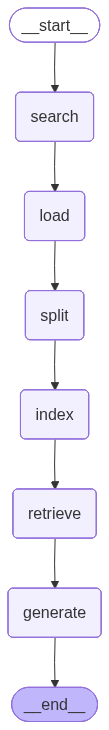

In [20]:
app

정상적으로 선언됐다는 것을 확인할 수 있습니다!!

과제에서는 웹 검색 기반이 아닌, 여러분들이 직접 pdf를 입력해서 답변을 생성하는 코드를 다룰 예정입니다!      

## langsmith

사실 아까 위해서 api 값 선언하는 코드 중에 그냥 넘어간 부분이 있는데, 해당 코드 중에서 langsmith 관련 내용이 있습니다

계정 api키를 입력하고 project 이름을 설정하고 langsmith 사이트에 들어가면, 추적을 할 수 있을거에요!

스스로 직접 확인하고 싶으면, langsmith 계정 만들고 설정값을 입력하시면 됩니다.

```
import os

# langsmith api키 (원한다면 본인 계정으로 넣어도 돼요)
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_API_KEY"] = "랭스미스 키 값 입력하기"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = "프로젝트명"
```